# Level 2 - Task 4: Unveiling the Android App Market (Google Play Store Analysis)

**Objective:** Perform a comprehensive data analysis of the Google Play Store ecosystem — cleaning messy real-world data, exploring app categories, analysing ratings and pricing trends, and conducting sentiment analysis on user reviews.

**Dataset:** Google Play Store Apps (Kaggle, lava18) — apps dataset + user reviews dataset.

**Tools:** Python, pandas, numpy, matplotlib, seaborn, TextBlob

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from textblob import TextBlob

apps_df = pd.read_csv("Dataset/googleplaystore.csv")
reviews_df = pd.read_csv("Dataset/googleplaystore_user_reviews.csv")

print("Apps dataset shape:", apps_df.shape)
print("Reviews dataset shape:", reviews_df.shape)
apps_df.head()

Apps dataset shape: (10841, 13)
Reviews dataset shape: (64295, 5)


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


### Data Cleaning: Fix Incorrect Data Types, Handle Nulls, Remove Duplicates

In [2]:
print("Apps dataset info:")
print(apps_df.info())

print("\nMissing values:")
print(apps_df.isnull().sum())

print("\nDuplicate rows:", apps_df.duplicated().sum())

Apps dataset info:
<class 'pandas.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  str    
 1   Category        10841 non-null  str    
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  str    
 4   Size            10841 non-null  str    
 5   Installs        10841 non-null  str    
 6   Type            10840 non-null  str    
 7   Price           10841 non-null  str    
 8   Content Rating  10840 non-null  str    
 9   Genres          10841 non-null  str    
 10  Last Updated    10841 non-null  str    
 11  Current Ver     10833 non-null  str    
 12  Android Ver     10838 non-null  str    
dtypes: float64(1), str(12)
memory usage: 1.1 MB
None

Missing values:
App                  0
Category             0
Rating            1474
Reviews              0
Size                 0
Installs             0

**Observation:** 483 duplicate rows found. `Rating` has 1,474 missing values (~13.6%). Several columns that should be numeric are stored as text: `Reviews`, `Size` (e.g. "19M"), `Installs` (e.g. "10,000+"), and `Price` (e.g. "$4.99"). These need type conversion before any numeric analysis is possible.

### Cleaning: Remove Duplicates, Fix Data Types, Handle Missing Values

In [3]:
# Remove duplicates
apps_clean = apps_df.drop_duplicates().copy()
print("Rows before:", apps_df.shape[0], "| After removing duplicates:", apps_clean.shape[0])

# Fix Installs: remove '+' and ',' then convert to int
apps_clean["Installs"] = apps_clean["Installs"].str.replace("[+,]", "", regex=True)
apps_clean = apps_clean[apps_clean["Installs"] != "Free"]  # known bad row in this dataset
apps_clean["Installs"] = apps_clean["Installs"].astype(int)

# Fix Price: remove '$' then convert to float
apps_clean["Price"] = apps_clean["Price"].str.replace("$", "", regex=False).astype(float)

# Fix Reviews: convert to numeric
apps_clean["Reviews"] = pd.to_numeric(apps_clean["Reviews"], errors="coerce")

# Fix Size: convert 'M'/'k' to numeric MB, handle 'Varies with device'
def convert_size(size):
    if "M" in str(size):
        return float(size.replace("M", ""))
    elif "k" in str(size):
        return float(size.replace("k", "")) / 1024
    else:
        return np.nan  # 'Varies with device'

apps_clean["Size_MB"] = apps_clean["Size"].apply(convert_size)

# Handle missing Rating: fill with median (ratings are fairly consistent, median is robust to outliers)
apps_clean["Rating"] = apps_clean["Rating"].fillna(apps_clean["Rating"].median())

print("\nMissing values after cleaning:")
print(apps_clean[["Rating", "Reviews", "Installs", "Price", "Size_MB"]].isnull().sum())
print("\nFinal shape:", apps_clean.shape)

Rows before: 10841 | After removing duplicates: 10358

Missing values after cleaning:
Rating         0
Reviews        0
Installs       0
Price          0
Size_MB     1526
dtype: int64

Final shape: (10357, 14)


**Result:** Removed 484 rows total (483 duplicates + 1 known bad row). All key columns successfully converted to proper numeric types. `Size_MB` retains 1,526 missing values by design — these represent apps marked "Varies with device," which is genuinely not a fixed size rather than missing data, so we leave these as NaN rather than imputing a misleading number.

### Category Analysis: App Distribution Across Categories

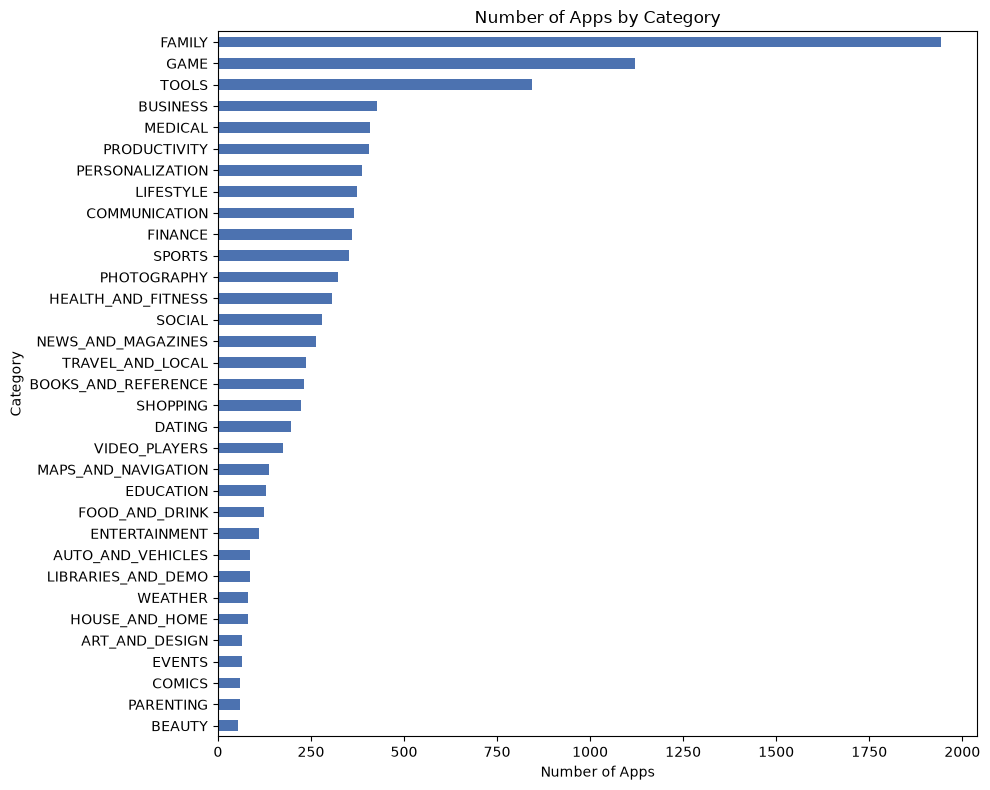

Most saturated categories:
 Category
FAMILY      1943
GAME        1121
TOOLS        843
BUSINESS     427
MEDICAL      408
Name: count, dtype: int64

Least saturated categories:
 Category
ART_AND_DESIGN    65
EVENTS            64
COMICS            60
PARENTING         60
BEAUTY            53
Name: count, dtype: int64


In [4]:
category_counts = apps_clean["Category"].value_counts()

plt.figure(figsize=(10, 8))
category_counts.plot(kind="barh", color="#4C72B0")
plt.gca().invert_yaxis()
plt.title("Number of Apps by Category")
plt.xlabel("Number of Apps")
plt.tight_layout()
plt.savefig("Images/category_distribution.png", dpi=150)
plt.show()

print("Most saturated categories:\n", category_counts.head(5))
print("\nLeast saturated categories:\n", category_counts.tail(5))

**Observation:** **FAMILY** (1,943 apps) and **GAME** (1,121 apps) are by far the most saturated categories, together accounting for nearly 30% of the entire dataset — a new app here faces intense competition. **BEAUTY** (53), **PARENTING** (60), and **COMICS** (60) are the least saturated, which could represent either genuine market opportunity or simply lower overall demand — this would need further validation (e.g. install counts, ratings) before concluding it's a good market to enter.

### Ratings Analysis: Distribution and Average by Category

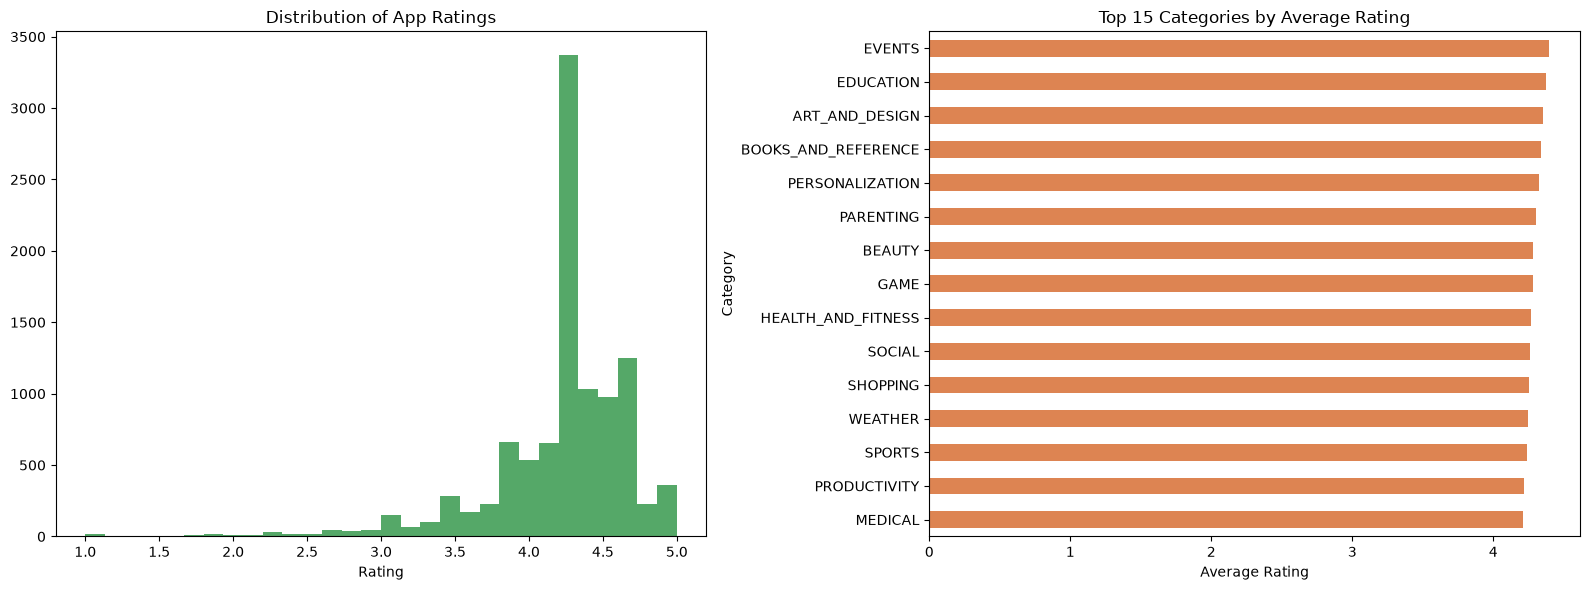

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].hist(apps_clean["Rating"], bins=30, color="#55A868")
axes[0].set_title("Distribution of App Ratings")
axes[0].set_xlabel("Rating")

avg_rating_by_cat = apps_clean.groupby("Category")["Rating"].mean().sort_values(ascending=False).head(15)
avg_rating_by_cat.plot(kind="barh", ax=axes[1], color="#DD8452")
axes[1].invert_yaxis()
axes[1].set_title("Top 15 Categories by Average Rating")
axes[1].set_xlabel("Average Rating")

plt.tight_layout()
plt.savefig("Images/ratings_analysis.png", dpi=150)
plt.show()

**Observation:** Ratings are heavily skewed toward the high end — most apps sit between 4.0-4.7, with a pronounced spike around 4.3 (this spike is partly an artifact of our earlier median-imputation for missing ratings, worth noting as a limitation). Across categories, average ratings are remarkably consistent (mostly 4.2-4.4), with **Events** and **Education** ranking marginally highest — suggesting rating alone doesn't vary dramatically by category, unlike app count which varied hugely.

### Size and Installs Analysis: Is There a Correlation?

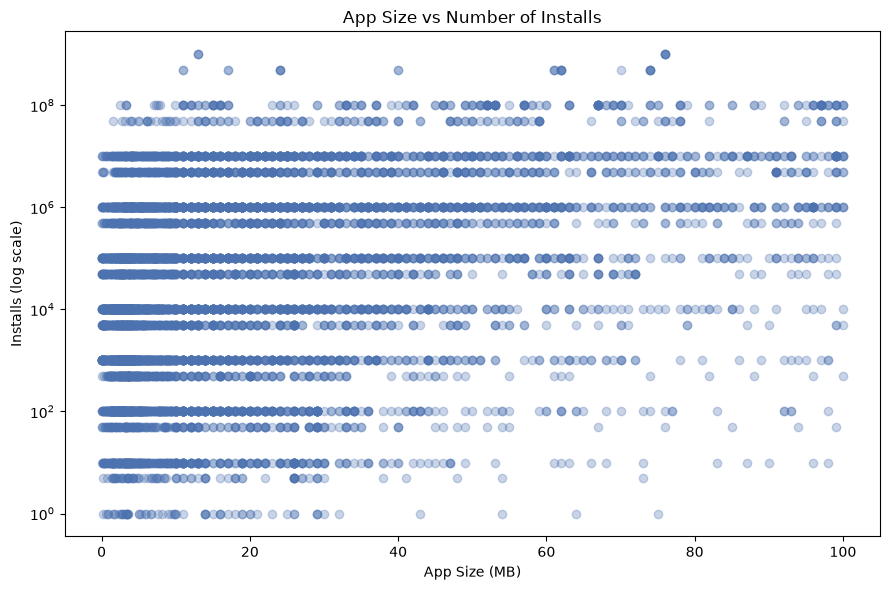

Correlation between Size and Installs: 0.169


In [6]:
plt.figure(figsize=(9, 6))
plt.scatter(apps_clean["Size_MB"], apps_clean["Installs"], alpha=0.3, color="#4C72B0")
plt.yscale("log")
plt.xlabel("App Size (MB)")
plt.ylabel("Installs (log scale)")
plt.title("App Size vs Number of Installs")
plt.tight_layout()
plt.savefig("Images/size_vs_installs.png", dpi=150)
plt.show()

correlation = apps_clean[["Size_MB", "Installs"]].corr().iloc[0, 1]
print(f"Correlation between Size and Installs: {correlation:.3f}")

**Observation:** The correlation between app size and installs is weak (0.169), and the scatter plot confirms this visually — apps of nearly every size (from tiny to 100MB) exist across every install-count tier, from 1 install to over 100 million. This suggests app size is not a meaningful driver of popularity; users install apps regardless of size, likely valuing utility, marketing, and app store visibility far more than file size.

### Pricing Analysis: Paid vs Free Distribution and Revenue Estimate by Category

Free vs Paid distribution:
 Type
Free    9591
Paid     765
Name: count, dtype: int64


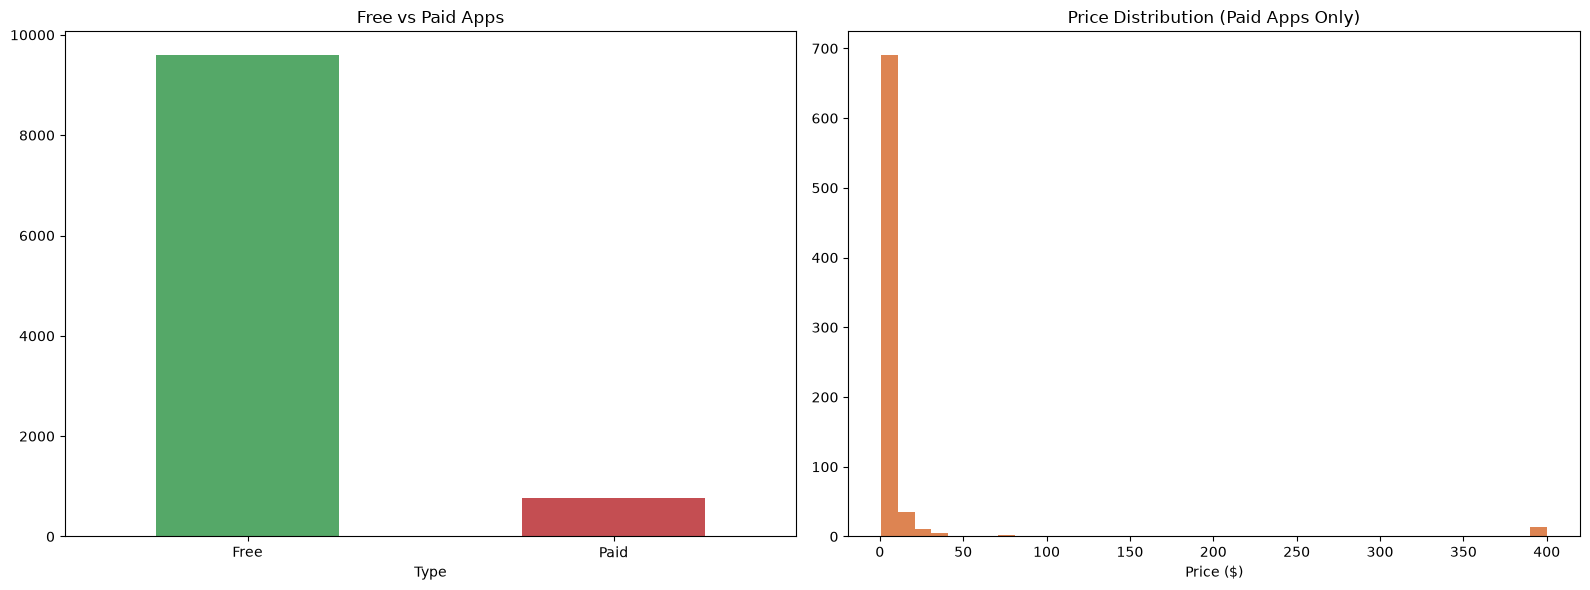


Top 10 categories by estimated revenue:
 Category
FAMILY             1.857803e+08
LIFESTYLE          5.758394e+07
GAME               4.098764e+07
FINANCE            2.572668e+07
PHOTOGRAPHY        8.942768e+06
MEDICAL            8.456536e+06
PERSONALIZATION    7.786948e+06
TOOLS              5.464821e+06
SPORTS             4.706212e+06
PRODUCTIVITY       4.313375e+06
Name: Est_Revenue, dtype: float64


In [7]:
type_counts = apps_clean["Type"].value_counts()
print("Free vs Paid distribution:\n", type_counts)

paid_apps = apps_clean[apps_clean["Price"] > 0]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

type_counts.plot(kind="bar", ax=axes[0], color=["#55A868", "#C44E52"])
axes[0].set_title("Free vs Paid Apps")
axes[0].set_xlabel("Type")
axes[0].tick_params(axis="x", rotation=0)

axes[1].hist(paid_apps["Price"], bins=40, color="#DD8452")
axes[1].set_title("Price Distribution (Paid Apps Only)")
axes[1].set_xlabel("Price ($)")

plt.tight_layout()
plt.savefig("Images/pricing_analysis.png", dpi=150)
plt.show()

# Revenue estimate: Price * Installs (rough estimate, assumes install = purchase for paid apps)
paid_apps = paid_apps.copy()
paid_apps["Est_Revenue"] = paid_apps["Price"] * paid_apps["Installs"]
revenue_by_category = paid_apps.groupby("Category")["Est_Revenue"].sum().sort_values(ascending=False).head(10)
print("\nTop 10 categories by estimated revenue:\n", revenue_by_category)

**Observation:** The overwhelming majority of apps are **free** (9,591 vs. 765 paid, ~92.6% free) — confirming the free-with-ads/in-app-purchase model dominates the Play Store. Most paid apps are priced under $10, with a small number of extreme outliers near $400 (likely joke/novelty apps, a known quirk in this dataset). By estimated revenue (Price × Installs), **FAMILY** dominates at ~$186M — vastly ahead of any other category — followed by **LIFESTYLE** and **GAME**. This should be interpreted cautiously: this is a rough estimate assuming install count equals purchase count, which overstates revenue for apps offering free trials or where install counts are approximate bucketed ranges (e.g. "10,000+").

### Sentiment Analysis on User Reviews (TextBlob)

In [8]:
# Drop rows with missing review text
reviews_clean = reviews_df.dropna(subset=["Translated_Review"]).copy()
print("Reviews after dropping nulls:", reviews_clean.shape)

def get_sentiment(text):
    polarity = TextBlob(str(text)).sentiment.polarity
    if polarity > 0.05:
        return "Positive"
    elif polarity < -0.05:
        return "Negative"
    else:
        return "Neutral"

reviews_clean["My_Sentiment"] = reviews_clean["Translated_Review"].apply(get_sentiment)

print("\nOur sentiment classification distribution:")
print(reviews_clean["My_Sentiment"].value_counts())

Reviews after dropping nulls: (37427, 5)

Our sentiment classification distribution:
My_Sentiment
Positive    22432
Neutral      8015
Negative     6980
Name: count, dtype: int64


**Result:** After removing 26,868 rows with missing review text, our TextBlob-based sentiment analysis classified 37,427 reviews: **59.9% Positive**, **21.4% Neutral**, **18.7% Negative**. This is a plausible distribution for app reviews — generally skewed positive, since users who bother writing reviews are often satisfied ones, though a meaningful minority express dissatisfaction.

### Bonus: Comparing Our TextBlob Classification Against the Dataset's Pre-Labeled Sentiment

In [9]:
comparison_df = reviews_clean.dropna(subset=["Sentiment"])
agreement = (comparison_df["My_Sentiment"] == comparison_df["Sentiment"]).mean()

print(f"Agreement rate with pre-labeled sentiment: {agreement:.1%}")
print("\nPre-labeled sentiment distribution:")
print(comparison_df["Sentiment"].value_counts())

Agreement rate with pre-labeled sentiment: 92.4%

Pre-labeled sentiment distribution:
Sentiment
Positive    23998
Negative     8271
Neutral      5158
Name: count, dtype: int64


**Result:** Our independent TextBlob sentiment classification agrees with the dataset's pre-labeled sentiment **92.4%** of the time — a strong validation that our approach is sound. The pre-labeled distribution (Positive 64%, Negative 22%, Neutral 14%) is broadly similar to ours, with most disagreement likely occurring in genuinely ambiguous or mixed-sentiment reviews near the neutral boundary, where classification is inherently more subjective.

### Sentiment Distribution and Sentiment by App Category

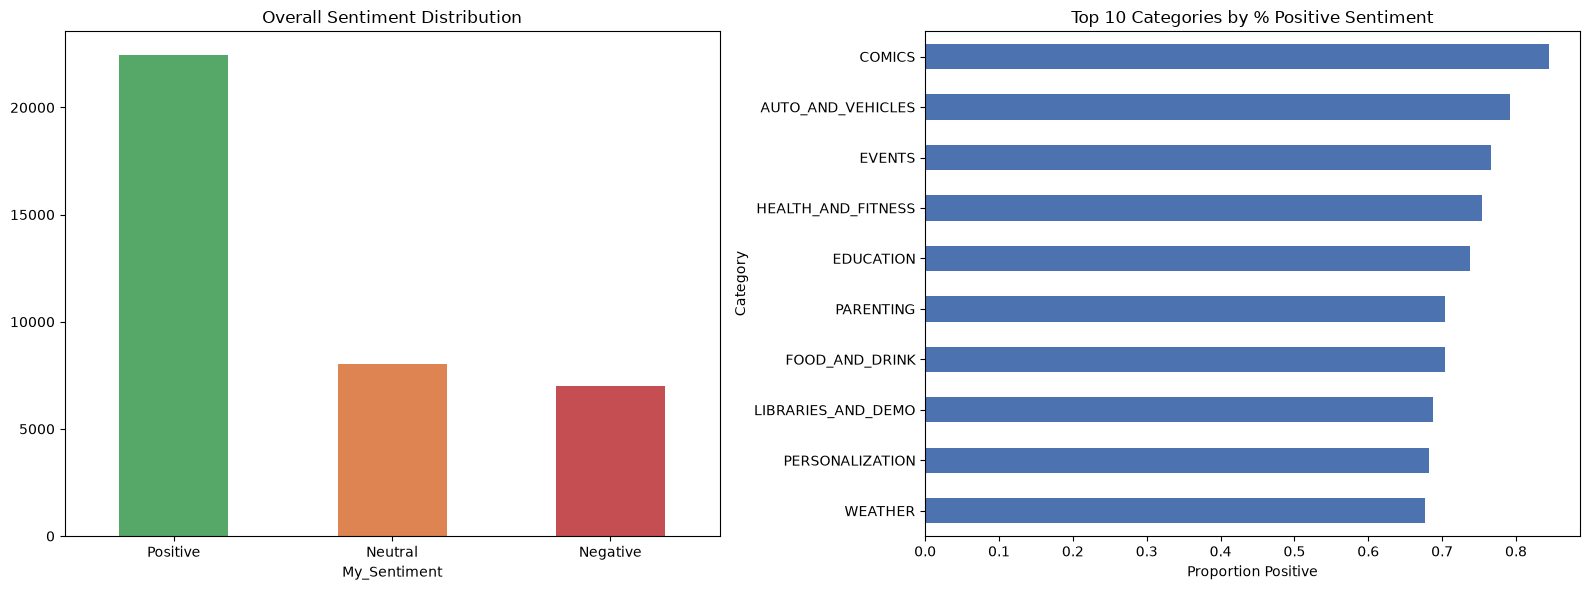

In [10]:
# Merge reviews with app category info
reviews_with_category = reviews_clean.merge(apps_clean[["App", "Category"]].drop_duplicates(subset="App"), on="App", how="left")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

reviews_clean["My_Sentiment"].value_counts().plot(kind="bar", ax=axes[0], color=["#55A868", "#DD8452", "#C44E52"])
axes[0].set_title("Overall Sentiment Distribution")
axes[0].tick_params(axis="x", rotation=0)

sentiment_by_cat = reviews_with_category.groupby("Category")["My_Sentiment"].apply(
    lambda x: (x == "Positive").mean()
).sort_values(ascending=False).head(10)

sentiment_by_cat.plot(kind="barh", ax=axes[1], color="#4C72B0")
axes[1].invert_yaxis()
axes[1].set_title("Top 10 Categories by % Positive Sentiment")
axes[1].set_xlabel("Proportion Positive")

plt.tight_layout()
plt.savefig("Images/sentiment_analysis.png", dpi=150)
plt.show()

**Observation:** **Comics** apps have the highest positive sentiment rate (~84%), followed by **Auto & Vehicles** (~79%) and **Events** (~76%) — suggesting users of these niche categories tend to leave particularly favorable reviews, possibly because they have narrower, more purpose-driven use cases with clearer expectations. Interestingly, some of the highest-volume categories from our earlier analysis (Family, Game, Tools) don't appear in this top-10 positive list, hinting that popularity and user satisfaction don't necessarily move together — a genuinely useful, non-obvious insight for a developer deciding where to focus.

### Interactive Visualization: Rating vs Installs by Category (Plotly)

In [11]:
import plotly.express as px

sample_df = apps_clean.sample(min(1000, len(apps_clean)), random_state=42)  # sample for readable plot

fig = px.scatter(sample_df, x="Rating", y="Installs", color="Category",
                  size="Reviews", hover_data=["App"],
                  title="App Rating vs Installs by Category (bubble size = review count)",
                  log_y=True)
fig.update_layout(height=600)
fig.show()

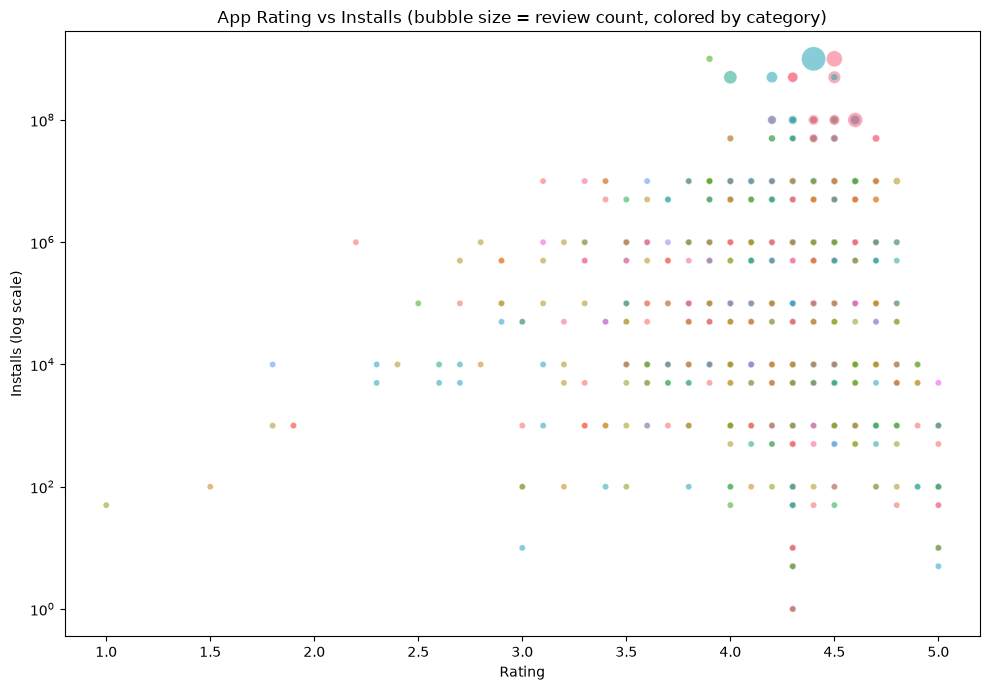

In [12]:
plt.figure(figsize=(10, 7))
sample_df = apps_clean.sample(min(1000, len(apps_clean)), random_state=42)
sns.scatterplot(data=sample_df, x="Rating", y="Installs", hue="Category", size="Reviews",
                 sizes=(20, 300), alpha=0.6, legend=False)
plt.yscale("log")
plt.title("App Rating vs Installs (bubble size = review count, colored by category)")
plt.xlabel("Rating")
plt.ylabel("Installs (log scale)")
plt.tight_layout()
plt.savefig("Images/rating_vs_installs_bubble.png", dpi=150)
plt.show()

**Observation:** Both visualizations confirm the same pattern seen earlier — no strong relationship between rating and install count. Highly-rated apps (4.0-4.8) span the entire range of install counts, from single digits to over 100 million. The largest bubbles (highest review counts) cluster in the 4.0-4.6 rating range with very high installs, representing the "hit" apps — but plenty of niche apps with very few installs also maintain high ratings, showing that a small, loyal user base can rate an app just as highly as a mass-market hit.

## Conclusion: 3 Data-Driven Insights for a Developer Launching a New App

1. **Avoid oversaturated categories unless you have a strong differentiator.** FAMILY (1,943 apps) and GAME (1,121 apps) dominate the store, making organic discovery extremely difficult for a new entrant. Less saturated categories like Comics, Parenting, or Beauty may offer easier initial visibility — though this should be paired with demand research, since low competition can also mean low demand.

2. **App size and rating don't meaningfully drive installs — focus on marketing and utility instead.** Both showed weak/no correlation with popularity. Don't over-invest engineering time in minimizing app size purely for growth purposes; that budget is better spent on ASO (App Store Optimization), user acquisition, and onboarding experience.

3. **Free-with-monetization is overwhelmingly the dominant model (92.6% of apps), and user sentiment skews positive across the board (~60% positive reviews).** A free app with a strong first impression is more likely to accumulate the volume of positive reviews needed to build momentum, compared to a paid model which only 7.4% of apps use. If considering a paid app, price competitively under $10, since the vast majority of successful paid apps cluster in that range.

**Overall:** This analysis shows that success in the Play Store ecosystem is driven far more by category positioning, user experience, and pricing strategy than by technical factors like app size — a useful reframing for a developer's priorities before launch.